# Ray Paths With `3D_Reference_Model_Margarit`

This notebook reuses the selected-event logic from the ray-path workflow, but computes only `P` travel times and ray paths in a spherical `pykonal` model where:

- the lunar surface radius is constant,
- crustal thickness and Moho depth vary laterally from the Kim et al. grid,
- the crustal `Vp/Vs/rho` structure is stretched from the 1D Garcia-style template,
- the mantle below the local Moho remains 1D.


In [276]:
# If needed, install the packages in this kernel first:
# %pip install numpy pandas matplotlib xarray openpyxl pykonal h5py obspy

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from IPython.display import display
from matplotlib.lines import Line2D

try:
    import pykonal
except ModuleNotFoundError:
    pykonal = None
    print("`pykonal` is not installed in this kernel. Install it with `%pip install pykonal h5py`.")

try:
    from obspy.taup import TauPyModel
    from obspy.taup.taup_create import build_taup_model
except ModuleNotFoundError:
    TauPyModel = None
    build_taup_model = None
    print("`obspy` is not installed in this kernel. Install it with `%pip install obspy`.")

RMOON_KM = 1737.4
PHASE_NAME = "P"
SOURCE_DEPTH_KM = 70.0
TAUP_MODEL_NAME = "vpremoon_mantle_closed"

GRAIL_GRID = Path("/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/data/raw/thick-2-35.5-12-3400.txt")
MODEL_FILE = Path("/Users/ramonmargarit/Desktop/vpremoon_mantle_closed.tvel")
SELECTED_EVENTS_DIR = Path(
    "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/selected_events"
)
XLSX = Path("/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/data/processed/Shallow_processed_RESULTS.xlsx")
SHEET = "best_7_bands_fixed_hold0"
RESULTS_CSV = Path(
    "/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/ray_paths_3d_reference_model_margarit.csv"
)
LOCAL_TAUP_DIR = RESULTS_CSV.parent / "taup_local_models"

FC = 5.0
BANDS = np.array([3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0])
SCENARIO_OPTIONS = {
    "relaxed_mp1_kn4_kpp2": dict(LOWER_TOL=0.75, MIN_POST=1, K_NEG=4, K_PRE_POS=2),
    "strict_mp4_kn0_kpp0": dict(LOWER_TOL=0.75, MIN_POST=4, K_NEG=0, K_PRE_POS=0),
    "legacy_mp0_kn5_kpp2": dict(LOWER_TOL=0.75, MIN_POST=0, K_NEG=5, K_PRE_POS=2),
    "mp2_kn0_kpp0": dict(LOWER_TOL=0.75, MIN_POST=2, K_NEG=0, K_PRE_POS=0),
    "mp2_kn1_kpp0": dict(LOWER_TOL=0.75, MIN_POST=2, K_NEG=1, K_PRE_POS=0),
    "mp2_kn1_kpp1": dict(LOWER_TOL=0.75, MIN_POST=2, K_NEG=1, K_PRE_POS=1),
    "mp2_kn2_kpp1": dict(LOWER_TOL=0.75, MIN_POST=2, K_NEG=2, K_PRE_POS=1),
    "mp2_kn3_kpp2": dict(LOWER_TOL=0.75, MIN_POST=2, K_NEG=3, K_PRE_POS=2),
}
EVENT_SELECTION_NAME = "legacy_mp0_kn5_kpp2"
SCENARIO = SCENARIO_OPTIONS[EVENT_SELECTION_NAME].copy()

APOLLO_STATIONS = {
    "S16": {"lat": -8.9730, "lon": 15.5000},
    "S14": {"lat": -3.6440, "lon": -17.4775},
    "S15": {"lat": 26.1322, "lon": 3.6339},
}

MAX_EVENTS = None

NXYZ = 62
TRACE_STEP_KM = 5.0
SOURCE_SEED_RADIUS_KM = 20.0
RECEIVER_DEPTH_KM = 1.0
TAUP_PATH_SAMPLES = 201


In [277]:
def _first_existing_col(cols, candidates):
    for col in candidates:
        if col in cols:
            return col
    return None


def _match_longitude(lon_values, query_lon_deg):
    lon_values = np.asarray(lon_values, dtype=float)
    if np.nanmin(lon_values) < 0:
        return ((query_lon_deg + 180.0) % 360.0) - 180.0
    return np.mod(query_lon_deg, 360.0)


def load_grail_crust(path):
    if not path.exists():
        raise FileNotFoundError(f"GRAIL crust file not found: {path}")

    grid_m = np.loadtxt(path)
    if grid_m.shape != (1803, 3605):
        raise ValueError(f"Unexpected Kim-grid shape: {grid_m.shape}. Expected (1803, 3605).")

    lat = np.linspace(90.0, -90.0, grid_m.shape[0])
    lon = np.linspace(0.0, 360.0, grid_m.shape[1])
    crust_km = xr.DataArray(
        grid_m / 1e3,
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name="crust_thickness_km",
        attrs={"units": "km", "source": str(path)},
    )
    return crust_km.sortby("lat").sortby("lon")


def read_vpremoon_model(model_file):
    rows = []
    started = False

    with open(model_file, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if not started:
                if len(parts) >= 4 and parts[0].lower() == "depth_km":
                    started = True
                continue

            if len(parts) < 4:
                continue

            try:
                rows.append([float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])])
            except ValueError:
                continue

    if not rows:
        raise ValueError(f"No model rows found in file: {model_file}")

    model_df = pd.DataFrame(rows, columns=["depth_km", "vp_km_s", "vs_km_s", "rho_g_cm3"])
    model_df["radius_km"] = RMOON_KM - model_df["depth_km"]
    return model_df


def collapse_depth_profile(model_df, keep):
    return model_df.sort_values("depth_km").drop_duplicates(subset="depth_km", keep=keep).reset_index(drop=True)


def interpolate_profile(depths_km, profile_df, column):
    x = profile_df["depth_km"].to_numpy(dtype=float)
    y = profile_df[column].to_numpy(dtype=float)
    return np.interp(np.asarray(depths_km, dtype=float), x, y, left=y[0], right=y[-1])


def sample_crust_thickness(grail_crust_km, lat_deg, lon_deg):
    lat_values = grail_crust_km["lat"].values.astype(float)
    lon_values = grail_crust_km["lon"].values.astype(float)
    crust_values = grail_crust_km.values.astype(float)

    lat_arr = np.asarray(lat_deg, dtype=float)
    lon_arr = np.mod(np.asarray(lon_deg, dtype=float), 360.0)

    dlat = float(lat_values[1] - lat_values[0])
    dlon = float(lon_values[1] - lon_values[0])

    lat_idx = np.rint((lat_arr - lat_values[0]) / dlat).astype(int)
    lon_idx = np.rint((lon_arr - lon_values[0]) / dlon).astype(int)

    lat_idx = np.clip(lat_idx, 0, len(lat_values) - 1)
    lon_idx = np.clip(lon_idx, 0, len(lon_values) - 1)

    sampled = crust_values[lat_idx, lon_idx]
    return float(sampled) if np.ndim(sampled) == 0 else sampled


def build_reference_model_margarit_3d(grail_crust_km, radial_model_df):
    reference_crust_thickness_km = float(
        radial_model_df.loc[
            radial_model_df["depth_km"].duplicated(keep=False) & (radial_model_df["depth_km"] <= 100.0),
            "depth_km",
        ].max()
    )

    crust_profile_df = collapse_depth_profile(
        radial_model_df.loc[radial_model_df["depth_km"] <= reference_crust_thickness_km], keep="first"
    )
    mantle_profile_df = collapse_depth_profile(
        radial_model_df.loc[radial_model_df["depth_km"] >= reference_crust_thickness_km], keep="last"
    )

    geometry_grid = xr.Dataset(
        {
            "surface_radius_km": xr.full_like(grail_crust_km, RMOON_KM).rename("surface_radius_km"),
            "crust_thickness_km": grail_crust_km,
            "moho_radius_km": (RMOON_KM - grail_crust_km).rename("moho_radius_km"),
        }
    )

    def sample_geometry(lat_deg, lon_deg):
        crust_thickness_km = sample_crust_thickness(grail_crust_km, lat_deg, lon_deg)
        return {
            "lat_deg": float(lat_deg),
            "lon_deg": float(lon_deg),
            "surface_radius_km": RMOON_KM,
            "crust_thickness_km": float(crust_thickness_km),
            "moho_radius_km": RMOON_KM - float(crust_thickness_km),
            "moho_depth_km": float(crust_thickness_km),
        }

    def sample_reference_profile(lat_deg, lon_deg, depth_grid_km):
        geometry = sample_geometry(lat_deg, lon_deg)
        depth_grid_km = np.asarray(depth_grid_km, dtype=float)

        if np.any(depth_grid_km < 0.0):
            raise ValueError("Depths must be non-negative and measured downward from the local surface.")

        local_crust_thickness_km = max(geometry["crust_thickness_km"], 1e-6)
        crust_mask = depth_grid_km <= local_crust_thickness_km

        reference_crust_depth_km = np.clip(
            depth_grid_km / local_crust_thickness_km * reference_crust_thickness_km,
            0.0,
            reference_crust_thickness_km,
        )
        reference_mantle_depth_km = reference_crust_thickness_km + np.clip(
            depth_grid_km - local_crust_thickness_km,
            0.0,
            None,
        )

        vp = np.empty_like(depth_grid_km)
        vs = np.empty_like(depth_grid_km)
        rho = np.empty_like(depth_grid_km)

        vp[crust_mask] = interpolate_profile(reference_crust_depth_km[crust_mask], crust_profile_df, "vp_km_s")
        vs[crust_mask] = interpolate_profile(reference_crust_depth_km[crust_mask], crust_profile_df, "vs_km_s")
        rho[crust_mask] = interpolate_profile(reference_crust_depth_km[crust_mask], crust_profile_df, "rho_g_cm3")

        vp[~crust_mask] = interpolate_profile(reference_mantle_depth_km[~crust_mask], mantle_profile_df, "vp_km_s")
        vs[~crust_mask] = interpolate_profile(reference_mantle_depth_km[~crust_mask], mantle_profile_df, "vs_km_s")
        rho[~crust_mask] = interpolate_profile(reference_mantle_depth_km[~crust_mask], mantle_profile_df, "rho_g_cm3")

        return pd.DataFrame(
            {
                "lat_deg": float(lat_deg),
                "lon_deg": float(lon_deg),
                "depth_from_surface_km": depth_grid_km,
                "radius_km": RMOON_KM - depth_grid_km,
                "distance_below_moho_km": np.maximum(depth_grid_km - geometry["crust_thickness_km"], 0.0),
                "region": np.where(crust_mask, "crust", "mantle_or_deeper"),
                "vp_km_s": vp,
                "vs_km_s": vs,
                "rho_g_cm3": rho,
                "surface_radius_km": RMOON_KM,
                "crust_thickness_km": geometry["crust_thickness_km"],
                "moho_radius_km": geometry["moho_radius_km"],
                "reference_crust_depth_km": reference_crust_depth_km,
                "reference_mantle_depth_km": reference_mantle_depth_km,
            }
        )

    return {
        "name": "3D_Reference_Model_Margarit",
        "geometry_grid": geometry_grid,
        "reference_profile_1d": radial_model_df,
        "reference_crust_thickness_km": reference_crust_thickness_km,
        "crust_profile_1d": crust_profile_df,
        "mantle_profile_1d": mantle_profile_df,
        "sample_geometry": sample_geometry,
        "sample_reference_profile": sample_reference_profile,
    }


def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(f"Missing columns in sheet '{sheet}': {missing}; available: {list(d.columns)}")

    d["station"] = d["station"].astype(str)
    d["fc_hz"] = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)
    d["starttime_dt"] = pd.to_datetime(d["starttime"], errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    lat_col = _first_existing_col(d.columns, ["lat", "Lat", "LAT", "latitude", "Latitude"])
    lon_col = _first_existing_col(d.columns, ["Lon", "lon", "LON", "longitude", "Longitude"])

    if lat_col is not None:
        d["lat"] = pd.to_numeric(d[lat_col], errors="coerce")
    else:
        d["lat"] = np.nan

    if lon_col is not None:
        d["Lon"] = pd.to_numeric(d[lon_col], errors="coerce")
    else:
        d["Lon"] = np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()
    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event",
        "station",
        "starttime_dt",
        "fc_hz",
        "dt_rel",
        "distance_deg",
        "lat",
        "Lon",
        "t0_dt_mean_dt",
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue

        if int((post_vals <= LOWER_TOL).sum()) > K_NEG:
            keep.append(False)
            continue

        pre_vals = dt[pre_bands].dropna()
        if int((pre_vals > LOWER_TOL).sum()) > K_PRE_POS:
            keep.append(False)
            continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


def build_selected_events_from_excel():
    df_long = load_excel_long(XLSX, SHEET, FC=FC, BANDS=BANDS)
    dt_mat = build_event_band_matrix(df_long, BANDS=BANDS)
    keep_mask = select_events(dt_mat=dt_mat, FC=FC, BANDS=BANDS, **SCENARIO)

    dist_map = df_long[["event", "distance_deg"]].drop_duplicates(subset=["event"]).set_index("event")["distance_deg"].to_dict()
    lat_map = df_long[["event", "lat"]].drop_duplicates(subset=["event"]).set_index("event")["lat"].to_dict()
    lon_map = df_long[["event", "Lon"]].drop_duplicates(subset=["event"]).set_index("event")["Lon"].to_dict()
    time_map = (
        df_long[df_long["band"] == FC][["event", "t0_dt_mean_dt"]]
        .dropna()
        .drop_duplicates(subset=["event"])
        .set_index("event")["t0_dt_mean_dt"]
        .to_dict()
    )

    rows = []
    for ev in keep_mask.index[keep_mask]:
        rows.append(
            dict(
                event=ev,
                time_utc=time_map.get(ev, pd.NaT),
                station=ev.split("__", 1)[-1],
                epi_deg=dist_map.get(ev, np.nan),
                lat=lat_map.get(ev, np.nan),
                Lon=lon_map.get(ev, np.nan),
            )
        )

    return pd.DataFrame(rows)


def scenario_filename_fragment(scenario):
    lower_tol = f"{float(scenario['LOWER_TOL']):.2f}".replace(".", "p")
    return (
        f"LOW{lower_tol}_MINPOST{int(scenario['MIN_POST'])}"
        f"_KNEG{int(scenario['K_NEG'])}_KPREPOS{int(scenario['K_PRE_POS'])}"
    )


def preferred_selected_events_csv(selected_events_dir, sheet, scenario):
    return Path(selected_events_dir) / f"selected_events_{sheet}_{scenario_filename_fragment(scenario)}.csv"


def load_selected_event_coordinates(selected_events_dir, sheet, scenario):
    selected_events_dir = Path(selected_events_dir)
    preferred_csv = preferred_selected_events_csv(selected_events_dir, sheet, scenario)
    candidate_paths = []
    if preferred_csv.exists():
        candidate_paths.append(preferred_csv)
    candidate_paths.extend(sorted(selected_events_dir.glob(f"selected_events_{sheet}_*.csv")))

    seen = set()
    unique_paths = []
    for p in candidate_paths:
        if p not in seen and p.exists():
            seen.add(p)
            unique_paths.append(p)

    frames = []
    for p in unique_paths:
        try:
            df = pd.read_csv(p)
        except Exception:
            continue
        keep_cols = [c for c in ["event", "lat", "Lon", "depth_km"] if c in df.columns]
        if "event" not in keep_cols:
            continue
        frames.append(df[keep_cols].copy())

    if not frames:
        return pd.DataFrame(columns=["event", "lat", "Lon", "depth_km"]), preferred_csv

    coords_df = pd.concat(frames, ignore_index=True)
    for col in ["lat", "Lon", "depth_km"]:
        if col not in coords_df.columns:
            coords_df[col] = np.nan
        coords_df[col] = pd.to_numeric(coords_df[col], errors="coerce")
    coords_df = coords_df.sort_values(["event"]).drop_duplicates(subset=["event"], keep="first")
    return coords_df[["event", "lat", "Lon", "depth_km"]], preferred_csv


def load_event_catalog():
    selected_df = build_selected_events_from_excel()
    coords_df, preferred_csv = load_selected_event_coordinates(SELECTED_EVENTS_DIR, SHEET, SCENARIO)

    if not coords_df.empty:
        selected_df = selected_df.drop(columns=[c for c in ["lat", "Lon", "depth_km"] if c in selected_df.columns])
        df = selected_df.merge(coords_df.drop_duplicates(subset=["event"]), on="event", how="left")
    else:
        df = selected_df.copy()

    df["station"] = df["station"].astype(str).str.strip()
    for col in ["epi_deg", "lat", "Lon"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    if "depth_km" in df.columns:
        df["depth_km"] = pd.to_numeric(df["depth_km"], errors="coerce")
    else:
        df["depth_km"] = SOURCE_DEPTH_KM

    n_before_coords = len(df)
    df = df[
        np.isfinite(df["epi_deg"]) &
        np.isfinite(df["lat"]) &
        np.isfinite(df["Lon"]) &
        df["station"].isin(APOLLO_STATIONS.keys())
    ].copy()
    df["depth_km"] = df["depth_km"].fillna(SOURCE_DEPTH_KM)

    df = df.sort_values(["epi_deg", "time_utc"], na_position="last").drop_duplicates(subset=["event"])
    print(f"Active scenario: {EVENT_SELECTION_NAME} -> {SCENARIO}")
    print(f"Preferred coordinate CSV: {preferred_csv}")
    print(f"Scenario-selected events before coordinate filtering: {n_before_coords}")
    print(f"Scenario-selected events with usable coordinates: {len(df)}")
    if MAX_EVENTS is not None:
        df = df.head(MAX_EVENTS)
        print(f"Events kept after MAX_EVENTS filter: {len(df)}")

    return df.reset_index(drop=True)


In [278]:
# import sys
# !"{sys.executable}" -m pip install scipy


In [279]:
grail_crust_km = load_grail_crust(GRAIL_GRID)
radial_model_df = read_vpremoon_model(MODEL_FILE)
Reference_Model_Margarit_3D = build_reference_model_margarit_3d(grail_crust_km, radial_model_df)

print(f"Model name: {Reference_Model_Margarit_3D['name']}")
print(f"Constant surface radius used in solver: {RMOON_KM:.1f} km")
print(f"Reference crust thickness from 1D template: {Reference_Model_Margarit_3D['reference_crust_thickness_km']:.1f} km")
print(
    "Kim crust min/mean/max (km): "
    f"{float(grail_crust_km.min()):.2f}, {float(grail_crust_km.mean()):.2f}, {float(grail_crust_km.max()):.2f}"
)

preview_profile_df = Reference_Model_Margarit_3D["sample_reference_profile"](
    lat_deg=0.0,
    lon_deg=3.6,
    depth_grid_km=np.array([0.0, 5.0, 10.0, 20.0, 35.0, 60.0, 100.0, 300.0]),
)
display(preview_profile_df.round(3))


Model name: 3D_Reference_Model_Margarit
Constant surface radius used in solver: 1737.4 km
Reference crust thickness from 1D template: 28.0 km
Kim crust min/mean/max (km): 6.06, 34.75, 62.61


,lat_deg,lon_deg,depth_from_surface_km,radius_km,distance_below_moho_km,region,vp_km_s,vs_km_s,rho_g_cm3,surface_radius_km,crust_thickness_km,moho_radius_km,reference_crust_depth_km,reference_mantle_depth_km
0,0.0,3.6,0.0,1737.4,0.00,crust,1.000,0.500,2.600,1737.4,35.44,1701.96,0.000,28.00
1,0.0,3.6,5.0,1732.4,0.00,crust,1.590,0.849,2.643,1737.4,35.44,1701.96,3.950,28.00
2,0.0,3.6,10.0,1727.4,0.00,crust,2.380,1.316,2.702,1737.4,35.44,1701.96,7.901,28.00
3,0.0,3.6,20.0,1717.4,0.00,crust,3.746,2.156,2.762,1737.4,35.44,1701.96,15.801,28.00
4,0.0,3.6,35.0,1702.4,0.00,crust,5.450,3.267,2.762,1737.4,35.44,1701.96,27.652,28.00
5,0.0,3.6,60.0,1677.4,24.56,mantle_or_deeper,7.560,4.345,3.316,1737.4,35.44,1701.96,28.000,52.56
6,0.0,3.6,100.0,1637.4,64.56,mantle_or_deeper,7.593,4.361,3.322,1737.4,35.44,1701.96,28.000,92.56
7,0.0,3.6,300.0,1437.4,264.56,mantle_or_deeper,7.753,4.441,3.352,1737.4,35.44,1701.96,28.000,292.56


In [280]:
def latlon_depth_to_xyz(lat_deg, lon_deg, depth_km=0.0, radius_km=RMOON_KM):
    lat_rad = np.deg2rad(lat_deg)
    lon_rad = np.deg2rad(lon_deg)
    radius = radius_km - depth_km
    x = radius * np.cos(lat_rad) * np.cos(lon_rad)
    y = radius * np.cos(lat_rad) * np.sin(lon_rad)
    z = radius * np.sin(lat_rad)
    return np.array([x, y, z], dtype=float)


def nearest_node_index_cartesian(coords, min_coords, dx, nxyz):
    idx = np.rint((np.asarray(coords, dtype=float) - min_coords) / dx).astype(int)
    idx = np.clip(idx, 0, nxyz - 1)
    return tuple(idx.tolist())


def build_velocity_grid_cartesian(reference_model):
    xyz_axis = np.linspace(-RMOON_KM, RMOON_KM, NXYZ)
    X, Y, Z = np.meshgrid(xyz_axis, xyz_axis, xyz_axis, indexing="ij")
    rr = np.sqrt(X * X + Y * Y + Z * Z)
    inside_mask = rr <= RMOON_KM

    safe_rr = np.where(rr > 0.0, rr, 1.0)
    lat_deg = np.rad2deg(np.arcsin(np.clip(Z / safe_rr, -1.0, 1.0)))
    lon_deg = np.mod(np.rad2deg(np.arctan2(Y, X)), 360.0)
    crust_thickness_km = sample_crust_thickness(reference_model["geometry_grid"]["crust_thickness_km"], lat_deg, lon_deg)

    local_depth_km = np.maximum(RMOON_KM - rr, 0.0)
    local_crust_thickness_km = np.maximum(crust_thickness_km, 1e-6)
    crust_mask = inside_mask & (local_depth_km <= local_crust_thickness_km)

    reference_crust_depth_km = np.clip(
        local_depth_km / local_crust_thickness_km * reference_model["reference_crust_thickness_km"],
        0.0,
        reference_model["reference_crust_thickness_km"],
    )
    reference_mantle_depth_km = reference_model["reference_crust_thickness_km"] + np.clip(
        local_depth_km - local_crust_thickness_km,
        0.0,
        None,
    )

    vp_crust = np.interp(
        reference_crust_depth_km.ravel(),
        reference_model["crust_profile_1d"]["depth_km"].to_numpy(dtype=float),
        reference_model["crust_profile_1d"]["vp_km_s"].to_numpy(dtype=float),
    ).reshape(reference_crust_depth_km.shape)
    vp_mantle = np.interp(
        reference_mantle_depth_km.ravel(),
        reference_model["mantle_profile_1d"]["depth_km"].to_numpy(dtype=float),
        reference_model["mantle_profile_1d"]["vp_km_s"].to_numpy(dtype=float),
    ).reshape(reference_mantle_depth_km.shape)

    surface_vp = float(reference_model["crust_profile_1d"]["vp_km_s"].iloc[0])
    velocity = np.where(crust_mask, vp_crust, vp_mantle)
    velocity[~inside_mask] = surface_vp
    velocity = np.maximum(velocity, 0.1)
    return velocity.astype(float), xyz_axis


def initialize_cartesian_point_source_seed(solver, src_xyz, seed_radius_km=SOURCE_SEED_RADIUS_KM):
    min_coords = np.asarray(solver.velocity.min_coords, dtype=float)
    dx = float(solver.velocity.node_intervals[0])
    nxyz = int(solver.velocity.npts[0])
    src_idx = np.asarray(nearest_node_index_cartesian(src_xyz, min_coords, dx, nxyz), dtype=int)
    half_window = max(1, int(np.ceil(seed_radius_km / dx)))

    ix = np.arange(max(0, src_idx[0] - half_window), min(nxyz, src_idx[0] + half_window + 1))
    iy = np.arange(max(0, src_idx[1] - half_window), min(nxyz, src_idx[1] + half_window + 1))
    iz = np.arange(max(0, src_idx[2] - half_window), min(nxyz, src_idx[2] + half_window + 1))
    IX, IY, IZ = np.meshgrid(ix, iy, iz, indexing="ij")
    pts = np.column_stack([
        min_coords[0] + IX.ravel() * dx,
        min_coords[1] + IY.ravel() * dx,
        min_coords[2] + IZ.ravel() * dx,
    ])
    dist = np.linalg.norm(pts - src_xyz[None, :], axis=1)
    keep = dist <= seed_radius_km

    seeded = 0
    for p, d in zip(pts[keep], dist[keep]):
        idx = nearest_node_index_cartesian(p, min_coords, dx, nxyz)
        vv = float(solver.velocity.values[idx])
        if not np.isfinite(vv) or vv <= 0.0:
            continue
        solver.traveltime.values[idx] = float(d / vv)
        solver.unknown[idx] = False
        solver.trial.push(*idx)
        seeded += 1

    src_tuple = tuple(src_idx.tolist())
    solver.traveltime.values[src_tuple] = 0.0
    solver.unknown[src_tuple] = False
    solver.trial.push(*src_tuple)
    return seeded + 1, src_tuple


def trace_ray_from_gradient_cartesian(field, end_xyz, src_xyz, step_km=TRACE_STEP_KM, max_steps=4000):
    point = np.asarray(end_xyz, dtype=float).copy()
    src = np.asarray(src_xyz, dtype=float)
    path = [point.copy()]
    diagnostics = []
    value = np.inf
    stop_reason = "max_steps"

    for step_index in range(max_steps):
        previous_value = value
        value = float(field.value(point))
        grad = np.asarray(field.gradient.value(point), dtype=float)
        grad_norm = float(np.linalg.norm(grad))
        source_distance = float(np.linalg.norm(point - src))
        diagnostics.append({
            "step": step_index,
            "x_km": float(point[0]),
            "y_km": float(point[1]),
            "z_km": float(point[2]),
            "travel_time_s": value,
            "grad_norm": grad_norm,
            "source_distance": source_distance,
        })

        if not np.isfinite(value):
            stop_reason = "nan_traveltime"
            break
        if value >= previous_value:
            if len(path) > 1:
                path.pop()
                diagnostics.pop()
            stop_reason = "non_decreasing_traveltime"
            break
        if source_distance <= 2.0 * step_km:
            stop_reason = "reached_source_tolerance"
            break
        if not np.isfinite(grad_norm) or grad_norm < 1e-12:
            stop_reason = "bad_gradient"
            break

        new_point = point - step_km * (grad / grad_norm)
        if np.linalg.norm(new_point - point) < 1e-8:
            stop_reason = "zero_step"
            break
        point = new_point
        path.append(point.copy())

    return np.vstack(path), pd.DataFrame(diagnostics), stop_reason


def load_or_build_taup_model(model_file=MODEL_FILE, model_name=TAUP_MODEL_NAME):
    if TauPyModel is None or build_taup_model is None:
        raise ModuleNotFoundError("`obspy` is required for TauP comparisons. Install it with `%pip install obspy`.")
    try:
        return TauPyModel(model=model_name)
    except Exception:
        build_taup_model(str(model_file), verbose=False)
        return TauPyModel(model=model_name)


def build_taup_reference(row, taup_model):
    source_depth_km = float(row.get("depth_km", SOURCE_DEPTH_KM))
    arrivals = taup_model.get_travel_times(
        source_depth_in_km=source_depth_km,
        distance_in_degree=float(row["epi_deg"]),
        phase_list=[PHASE_NAME],
        receiver_depth_in_km=RECEIVER_DEPTH_KM,
    )
    if not arrivals:
        return {"travel_time_s": np.nan, "phase_name": None}
    first = min(arrivals, key=lambda a: a.time)
    return {"travel_time_s": float(first.time), "phase_name": first.name}


def local_taup_model_stem(role_tag, lat_deg, lon_deg, crust_thickness_km):
    stem = (
        f"{role_tag}_lat_{lat_deg:+08.3f}_lon_{np.mod(lon_deg, 360.0):08.3f}_"
        f"crust_{crust_thickness_km:06.3f}"
    )
    return stem.replace("+", "p").replace("-", "m").replace(".", "p")


def build_local_taup_profile(reference_model, lat_deg, lon_deg):
    geometry = reference_model["sample_geometry"](lat_deg, lon_deg)
    local_crust_thickness_km = max(float(geometry["crust_thickness_km"]), 1e-6)
    reference_crust_thickness_km = float(reference_model["reference_crust_thickness_km"])
    profile_df = reference_model["reference_profile_1d"].copy()

    depth_ref = profile_df["depth_km"].to_numpy(dtype=float)
    depth_local = np.where(
        depth_ref <= reference_crust_thickness_km,
        depth_ref / reference_crust_thickness_km * local_crust_thickness_km,
        local_crust_thickness_km + (depth_ref - reference_crust_thickness_km),
    )
    profile_df["depth_km"] = depth_local
    profile_df["radius_km"] = RMOON_KM - depth_local
    return profile_df, geometry


def write_taup_tvel(profile_df, output_path, title):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    lines = [title, "depth_km  vp_km_s  vs_km_s  rho_g_cm3"]
    for row in profile_df[["depth_km", "vp_km_s", "vs_km_s", "rho_g_cm3"]].itertuples(index=False):
        lines.append(f"{row.depth_km:.6f} {row.vp_km_s:.6f} {row.vs_km_s:.6f} {row.rho_g_cm3:.6f}")
    output_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return output_path


def load_or_build_local_taup_model(reference_model, lat_deg, lon_deg, role_tag, cache_dir=LOCAL_TAUP_DIR):
    if TauPyModel is None or build_taup_model is None:
        raise ModuleNotFoundError("`obspy` is required for TauP comparisons. Install it with `%pip install obspy`.")

    profile_df, geometry = build_local_taup_profile(reference_model, lat_deg, lon_deg)
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    model_stem = local_taup_model_stem(role_tag, lat_deg, lon_deg, geometry["crust_thickness_km"])
    tvel_path = cache_dir / f"{model_stem}.tvel"
    npz_path = cache_dir / f"{model_stem}.npz"

    if not npz_path.exists():
        title = (
            f"3D_Reference_Model_Margarit local TauP model ({role_tag}) "
            f"lat={float(lat_deg):.3f} lon={float(np.mod(lon_deg, 360.0)):.3f} "
            f"crust={float(geometry['crust_thickness_km']):.3f} km"
        )
        write_taup_tvel(profile_df, tvel_path, title)
        build_taup_model(str(tvel_path), output_folder=str(cache_dir), verbose=False)

    return TauPyModel(model=str(npz_path)), {
        "model_stem": model_stem,
        "tvel_path": str(tvel_path),
        "npz_path": str(npz_path),
        "crust_thickness_km": float(geometry["crust_thickness_km"]),
        "lat_deg": float(lat_deg),
        "lon_deg": float(np.mod(lon_deg, 360.0)),
    }


def arrival_to_path_df(arrival):
    if arrival is None or getattr(arrival, "path", None) is None or len(arrival.path) == 0:
        return None
    path = arrival.path
    return pd.DataFrame(
        {
            "distance_deg": np.rad2deg(path["dist"].astype(float)),
            "depth_km": path["depth"].astype(float),
            "radius_km": RMOON_KM - path["depth"].astype(float),
            "time_s": path["time"].astype(float),
        }
    )


def average_taup_path_frames(source_path_df, receiver_path_df, distance_deg, n_samples=TAUP_PATH_SAMPLES):
    if source_path_df is None or receiver_path_df is None:
        return None

    target_fraction = np.linspace(0.0, 1.0, n_samples)

    def _interp_path(df, column):
        dist = df["distance_deg"].to_numpy(dtype=float)
        if len(dist) == 0 or not np.isfinite(dist[-1]) or dist[-1] <= 0.0:
            return np.full_like(target_fraction, np.nan, dtype=float)
        fraction = dist / dist[-1]
        fraction = np.maximum.accumulate(fraction + np.linspace(0.0, 1e-10, len(fraction)))
        return np.interp(target_fraction, fraction, df[column].to_numpy(dtype=float))

    depth_source = _interp_path(source_path_df, "depth_km")
    depth_receiver = _interp_path(receiver_path_df, "depth_km")
    time_source = _interp_path(source_path_df, "time_s")
    time_receiver = _interp_path(receiver_path_df, "time_s")

    return pd.DataFrame(
        {
            "path_fraction": target_fraction,
            "distance_deg": target_fraction * float(distance_deg),
            "depth_source_local_km": depth_source,
            "depth_receiver_local_km": depth_receiver,
            "depth_mean_km": 0.5 * (depth_source + depth_receiver),
            "radius_mean_km": RMOON_KM - 0.5 * (depth_source + depth_receiver),
            "time_source_local_s": time_source,
            "time_receiver_local_s": time_receiver,
            "time_mean_s": 0.5 * (time_source + time_receiver),
        }
    )


def taup_path_to_xyz(path_df, source_xyz, receiver_xyz):
    if path_df is None or len(path_df) == 0:
        return None

    u_source = np.asarray(source_xyz, dtype=float)
    u_receiver = np.asarray(receiver_xyz, dtype=float)
    u_source = u_source / np.linalg.norm(u_source)
    u_receiver = u_receiver / np.linalg.norm(u_receiver)

    plane_normal = np.cross(u_source, u_receiver)
    plane_norm = float(np.linalg.norm(plane_normal))
    if plane_norm < 1e-12:
        return None
    plane_normal /= plane_norm
    tangent = np.cross(plane_normal, u_source)
    tangent /= np.linalg.norm(tangent)

    psi = np.deg2rad(path_df["distance_deg"].to_numpy(dtype=float))
    radii = path_df["radius_mean_km"].to_numpy(dtype=float) if "radius_mean_km" in path_df else path_df["radius_km"].to_numpy(dtype=float)
    directions = np.cos(psi)[:, None] * u_source[None, :] + np.sin(psi)[:, None] * tangent[None, :]
    directions /= np.linalg.norm(directions, axis=1)[:, None]
    return directions * radii[:, None]


def build_local_taup_reference(row, reference_model, role_tag):
    source_depth_km = float(row.get("depth_km", SOURCE_DEPTH_KM))
    if role_tag == "source":
        lat_deg = float(row["lat"])
        lon_deg = float(row["Lon"])
    elif role_tag == "receiver":
        station = APOLLO_STATIONS[row["station"]]
        lat_deg = float(station["lat"])
        lon_deg = float(station["lon"])
    else:
        raise ValueError(f"Unknown role_tag: {role_tag}")

    taup_model, model_info = load_or_build_local_taup_model(reference_model, lat_deg, lon_deg, role_tag)
    arrivals = taup_model.get_ray_paths(
        source_depth_in_km=source_depth_km,
        distance_in_degree=float(row["epi_deg"]),
        phase_list=[PHASE_NAME],
        receiver_depth_in_km=RECEIVER_DEPTH_KM,
    )
    if not arrivals:
        return {
            "travel_time_s": np.nan,
            "phase_name": None,
            "path_df": None,
            "model_info": model_info,
        }

    first = min(arrivals, key=lambda a: a.time)
    return {
        "travel_time_s": float(first.time),
        "phase_name": first.name,
        "path_df": arrival_to_path_df(first),
        "model_info": model_info,
    }


def solve_event_with_pykonal_cartesian(row, velocity, xyz_axis):
    if pykonal is None:
        raise ModuleNotFoundError("`pykonal` is required to solve the travel times in this notebook.")

    dx = float(xyz_axis[1] - xyz_axis[0])
    solver = pykonal.EikonalSolver(coord_sys="cartesian")
    solver.velocity.min_coords = (-RMOON_KM, -RMOON_KM, -RMOON_KM)
    solver.velocity.node_intervals = (dx, dx, dx)
    solver.velocity.npts = (NXYZ, NXYZ, NXYZ)
    solver.velocity.values = velocity

    source_depth_km = float(row.get("depth_km", SOURCE_DEPTH_KM))
    src_xyz = latlon_depth_to_xyz(float(row["lat"]), float(row["Lon"]), source_depth_km)
    station = APOLLO_STATIONS[row["station"]]
    rec_xyz = latlon_depth_to_xyz(station["lat"], station["lon"], RECEIVER_DEPTH_KM)

    seeded_nodes, src_idx = initialize_cartesian_point_source_seed(solver, src_xyz)
    rec_idx = nearest_node_index_cartesian(rec_xyz, np.asarray(solver.velocity.min_coords, dtype=float), dx, NXYZ)
    solver.solve()

    travel_time_s = float(solver.traveltime.value(rec_xyz))
    ray_xyz, ray_diag_df, trace_stop_reason = trace_ray_from_gradient_cartesian(solver.traveltime, rec_xyz, src_xyz)
    ray_depth_km = RMOON_KM - np.linalg.norm(ray_xyz, axis=1)

    return {
        "event": row["event"],
        "station": row["station"],
        "epi_deg": float(row["epi_deg"]),
        "src_lat": float(row["lat"]),
        "src_lon": float(row["Lon"]),
        "src_depth_km": source_depth_km,
        "travel_time_s": travel_time_s,
        "trace_method": "gradient_cartesian",
        "seeded_nodes": seeded_nodes,
        "src_idx": src_idx,
        "rec_idx": rec_idx,
        "trace_stop_reason": trace_stop_reason,
        "ray_xyz": ray_xyz,
        "ray_depth_km": ray_depth_km,
        "ray_diag_df": ray_diag_df,
        "source_xyz": src_xyz,
        "receiver_xyz": rec_xyz,
    }


In [281]:
catalog_df = load_event_catalog()
velocity_3d, xyz_axis = build_velocity_grid_cartesian(Reference_Model_Margarit_3D)
taup_model = load_or_build_taup_model()
LOCAL_TAUP_DIR.mkdir(parents=True, exist_ok=True)

print(f"Events loaded: {len(catalog_df)}")
print(f"Velocity grid shape: {velocity_3d.shape}")
print(f"Velocity min/max (km/s): {float(np.nanmin(velocity_3d)):.3f}, {float(np.nanmax(velocity_3d)):.3f}")
print(f"TauP model ready: {TAUP_MODEL_NAME}")
print(f"Active scenario name: {EVENT_SELECTION_NAME}")
print(f"Active scenario rule: {SCENARIO}")
print(f"Local TauP cache: {LOCAL_TAUP_DIR}")
display(catalog_df[["event", "station", "epi_deg", "lat", "Lon", "depth_km"]])


Active scenario: legacy_mp0_kn5_kpp2 -> {'LOWER_TOL': 0.75, 'MIN_POST': 0, 'K_NEG': 5, 'K_PRE_POS': 2}
Preferred coordinate CSV: /Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/selected_events/selected_events_best_7_bands_fixed_hold0_LOW0p75_MINPOST0_KNEG5_KPREPOS2.csv
Scenario-selected events before coordinate filtering: 43
Scenario-selected events with usable coordinates: 37
Events loaded: 37
Velocity grid shape: (62, 62, 62)
Velocity min/max (km/s): 1.000, 8.230
TauP model ready: vpremoon_mantle_closed
Active scenario name: legacy_mp0_kn5_kpp2
Active scenario rule: {'LOWER_TOL': 0.75, 'MIN_POST': 0, 'K_NEG': 5, 'K_PRE_POS': 2}
Local TauP cache: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/taup_local_models


,event,station,epi_deg,lat,Lon,depth_km
0,1975-02-13 21:54:00.011000+00:00__S14,S14,15.812846,-17.0,-26.1,70.0
1,1976-03-08 14:33:00.012000+00:00__S14,S14,15.971745,-19.0,-13.0,70.0
2,1973-02-08 22:43:10.015000+00:00__S15,S15,28.000000,33.0,35.0,70.0
3,1976-03-08 14:33:00.004000+00:00__S16,S16,29.358303,-19.0,-13.0,70.0
4,1976-01-04 11:09:00.018000+00:00__S15,S15,30.373555,44.1,34.0,70.0
5,1975-01-13 00:17:20.011000+00:00__S14,S14,33.000000,-2.0,-51.0,70.0
6,1976-03-06 10:03:00.015000+00:00__S15,S15,34.369254,52.5,-25.8,70.0
7,1972-12-06 22:59:00.004000+00:00__S15,S15,34.718490,48.0,38.2,70.0
8,1976-01-12 08:09:05.013000+00:00__S15,S15,35.000000,38.0,44.0,70.0
9,1974-04-19 13:26:15.008000+00:00__S16,S16,36.000000,-37.0,42.0,70.0


In [282]:
result_columns = [
    "event",
    "station",
    "epi_deg",
    "src_lat",
    "src_lon",
    "src_depth_km",
    "travel_time_pykonal_s",
    "travel_time_taup_s",
    "travel_time_taup_source_local_s",
    "travel_time_taup_receiver_local_s",
    "travel_time_taup_local_mean_s",
    "delta_t_pykonal_minus_taup_s",
    "delta_t_pykonal_minus_taup_local_mean_s",
    "delta_t_taup_local_mean_minus_taup_s",
    "phase",
    "taup_phase_name",
    "taup_source_local_phase_name",
    "taup_receiver_local_phase_name",
    "source_local_crust_thickness_km",
    "receiver_local_crust_thickness_km",
    "trace_method",
    "seeded_nodes",
    "trace_stop_reason",
]

solutions = []
skipped_events = []
for row in catalog_df.to_dict(orient="records"):
    epi_deg = pd.to_numeric(row.get("epi_deg", np.nan), errors="coerce")
    if not np.isfinite(epi_deg):
        skipped_events.append({"event": row.get("event"), "reason": "missing epi_deg"})
        continue

    row["epi_deg"] = float(epi_deg)
    sol = solve_event_with_pykonal_cartesian(row, velocity_3d, xyz_axis)
    taup_ref = build_taup_reference(row, taup_model)
    taup_source = build_local_taup_reference(row, Reference_Model_Margarit_3D, role_tag="source")
    taup_receiver = build_local_taup_reference(row, Reference_Model_Margarit_3D, role_tag="receiver")

    local_times = np.array([taup_source["travel_time_s"], taup_receiver["travel_time_s"]], dtype=float)
    local_mean_time = float(np.nanmean(local_times)) if np.any(np.isfinite(local_times)) else np.nan
    local_mean_path_df = average_taup_path_frames(
        taup_source["path_df"],
        taup_receiver["path_df"],
        distance_deg=float(row["epi_deg"]),
    )
    local_mean_ray_xyz = taup_path_to_xyz(local_mean_path_df, sol["source_xyz"], sol["receiver_xyz"]) if local_mean_path_df is not None else None

    sol["taup_travel_time_s"] = taup_ref["travel_time_s"]
    sol["taup_phase_name"] = taup_ref["phase_name"]
    sol["taup_source_local_travel_time_s"] = taup_source["travel_time_s"]
    sol["taup_source_local_phase_name"] = taup_source["phase_name"]
    sol["taup_source_local_path_df"] = taup_source["path_df"]
    sol["taup_source_local_model_info"] = taup_source["model_info"]
    sol["taup_receiver_local_travel_time_s"] = taup_receiver["travel_time_s"]
    sol["taup_receiver_local_phase_name"] = taup_receiver["phase_name"]
    sol["taup_receiver_local_path_df"] = taup_receiver["path_df"]
    sol["taup_receiver_local_model_info"] = taup_receiver["model_info"]
    sol["taup_local_mean_travel_time_s"] = local_mean_time
    sol["taup_local_mean_path_df"] = local_mean_path_df
    sol["taup_local_mean_ray_xyz"] = local_mean_ray_xyz
    solutions.append(sol)

result_rows = [
    {
        "event": sol["event"],
        "station": sol["station"],
        "epi_deg": sol["epi_deg"],
        "src_lat": sol["src_lat"],
        "src_lon": sol["src_lon"],
        "src_depth_km": sol["src_depth_km"],
        "travel_time_pykonal_s": sol["travel_time_s"],
        "travel_time_taup_s": sol["taup_travel_time_s"],
        "travel_time_taup_source_local_s": sol["taup_source_local_travel_time_s"],
        "travel_time_taup_receiver_local_s": sol["taup_receiver_local_travel_time_s"],
        "travel_time_taup_local_mean_s": sol["taup_local_mean_travel_time_s"],
        "delta_t_pykonal_minus_taup_s": sol["travel_time_s"] - sol["taup_travel_time_s"],
        "delta_t_pykonal_minus_taup_local_mean_s": sol["travel_time_s"] - sol["taup_local_mean_travel_time_s"],
        "delta_t_taup_local_mean_minus_taup_s": sol["taup_local_mean_travel_time_s"] - sol["taup_travel_time_s"],
        "phase": PHASE_NAME,
        "taup_phase_name": sol["taup_phase_name"],
        "taup_source_local_phase_name": sol["taup_source_local_phase_name"],
        "taup_receiver_local_phase_name": sol["taup_receiver_local_phase_name"],
        "source_local_crust_thickness_km": sol["taup_source_local_model_info"]["crust_thickness_km"],
        "receiver_local_crust_thickness_km": sol["taup_receiver_local_model_info"]["crust_thickness_km"],
        "trace_method": sol["trace_method"],
        "seeded_nodes": sol["seeded_nodes"],
        "trace_stop_reason": sol["trace_stop_reason"],
    }
    for sol in solutions
]

results_df = pd.DataFrame(result_rows, columns=result_columns)
if not results_df.empty:
    results_df = results_df.sort_values(["epi_deg", "station"]).reset_index(drop=True)

RESULTS_CSV.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(RESULTS_CSV, index=False)

display(results_df)
if skipped_events:
    print(f"Skipped events without usable epi_deg: {len(skipped_events)}")
if results_df.empty:
    print("No events with usable epicentral distance. Results table is empty.")
else:
    taup_summary_cols = [
        "event",
        "station",
        "travel_time_taup_source_local_s",
        "travel_time_taup_receiver_local_s",
        "travel_time_taup_local_mean_s",
    ]
    print("TauP local travel times (s):")
    display(results_df[taup_summary_cols])
    print(f"Mean residual (pykonal - TauP 1D Garcia): {results_df['delta_t_pykonal_minus_taup_s'].mean():.3f} s")
    print(f"Mean residual (pykonal - TauP local mean): {results_df['delta_t_pykonal_minus_taup_local_mean_s'].mean():.3f} s")
    print(f"RMS residual vs TauP 1D Garcia: {np.sqrt(np.mean(results_df['delta_t_pykonal_minus_taup_s'] ** 2)):.3f} s")
    print(f"RMS residual vs TauP local mean: {np.sqrt(np.mean(results_df['delta_t_pykonal_minus_taup_local_mean_s'] ** 2)):.3f} s")
print(f"Saved results to: {RESULTS_CSV}")


,event,station,epi_deg,src_lat,src_lon,src_depth_km,travel_time_pykonal_s,travel_time_taup_s,travel_time_taup_source_local_s,travel_time_taup_receiver_local_s,...,delta_t_taup_local_mean_minus_taup_s,phase,taup_phase_name,taup_source_local_phase_name,taup_receiver_local_phase_name,source_local_crust_thickness_km,receiver_local_crust_thickness_km,trace_method,seeded_nodes,trace_stop_reason
0,1975-02-13 21:54:00.011000+00:00__S14,S14,15.812846,-17.0,-26.1,70.0,90.247350,66.834407,66.850068,68.044902,...,0.613079,P,P,P,P,28.068079,33.243567,gradient_cartesian,1,non_decreasing_traveltime
1,1976-03-08 14:33:00.012000+00:00__S14,S14,15.971745,-19.0,-13.0,70.0,88.597166,67.443620,67.405813,68.655978,...,0.587275,P,P,P,P,27.815962,33.243567,gradient_cartesian,1,non_decreasing_traveltime
2,1973-02-08 22:43:10.015000+00:00__S15,S15,28.000000,33.0,35.0,70.0,138.137449,113.056824,115.299440,113.925563,...,1.555677,P,P,P,P,36.768021,31.400265,gradient_cartesian,1,non_decreasing_traveltime
3,1976-03-08 14:33:00.004000+00:00__S16,S16,29.358303,-19.0,-13.0,70.0,141.356842,118.119226,118.076387,120.853045,...,1.345490,P,P,P,P,27.815962,38.578909,gradient_cartesian,1,non_decreasing_traveltime
4,1976-01-04 11:09:00.018000+00:00__S15,S15,30.373555,44.1,34.0,70.0,146.455732,121.888578,120.643129,122.772511,...,-0.180758,P,P,P,P,22.686107,31.400265,gradient_cartesian,2,non_decreasing_traveltime
5,1975-01-13 00:17:20.011000+00:00__S14,S14,33.000000,-2.0,-51.0,70.0,152.759913,131.579390,132.789112,132.967819,...,1.299075,P,P,P,P,32.569410,33.243567,gradient_cartesian,1,non_decreasing_traveltime
6,1976-03-06 10:03:00.015000+00:00__S15,S15,34.369254,52.5,-25.8,70.0,160.860107,136.604240,136.836719,137.508865,...,0.568552,P,P,P,P,28.874583,31.400265,gradient_cartesian,1,non_decreasing_traveltime
7,1972-12-06 22:59:00.004000+00:00__S15,S15,34.718490,48.0,38.2,70.0,163.384345,137.883093,138.027744,138.789228,...,0.525393,P,P,P,P,28.543355,31.400265,gradient_cartesian,1,non_decreasing_traveltime
8,1976-01-12 08:09:05.013000+00:00__S15,S15,35.000000,38.0,44.0,70.0,171.582238,138.913001,139.854308,139.820431,...,0.924368,P,P,P,P,31.527082,31.400265,gradient_cartesian,1,non_decreasing_traveltime
9,1974-04-19 13:26:15.008000+00:00__S16,S16,36.000000,-37.0,42.0,70.0,168.473989,142.564800,144.882644,145.407588,...,2.580316,P,P,P,P,36.629713,38.578909,gradient_cartesian,2,non_decreasing_traveltime


TauP local travel times (s):


,event,station,travel_time_taup_source_local_s,travel_time_taup_receiver_local_s,travel_time_taup_local_mean_s
0,1975-02-13 21:54:00.011000+00:00__S14,S14,66.850068,68.044902,67.447485
1,1976-03-08 14:33:00.012000+00:00__S14,S14,67.405813,68.655978,68.030896
2,1973-02-08 22:43:10.015000+00:00__S15,S15,115.299440,113.925563,114.612502
3,1976-03-08 14:33:00.004000+00:00__S16,S16,118.076387,120.853045,119.464716
4,1976-01-04 11:09:00.018000+00:00__S15,S15,120.643129,122.772511,121.707820
5,1975-01-13 00:17:20.011000+00:00__S14,S14,132.789112,132.967819,132.878465
6,1976-03-06 10:03:00.015000+00:00__S15,S15,136.836719,137.508865,137.172792
7,1972-12-06 22:59:00.004000+00:00__S15,S15,138.027744,138.789228,138.408486
8,1976-01-12 08:09:05.013000+00:00__S15,S15,139.854308,139.820431,139.837369
9,1974-04-19 13:26:15.008000+00:00__S16,S16,144.882644,145.407588,145.145116


Mean residual (pykonal - TauP 1D Garcia): 22.720 s
Mean residual (pykonal - TauP local mean): 21.503 s
RMS residual vs TauP 1D Garcia: 22.893 s
RMS residual vs TauP local mean: 21.696 s
Saved results to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/ray_paths_3d_reference_model_margarit.csv


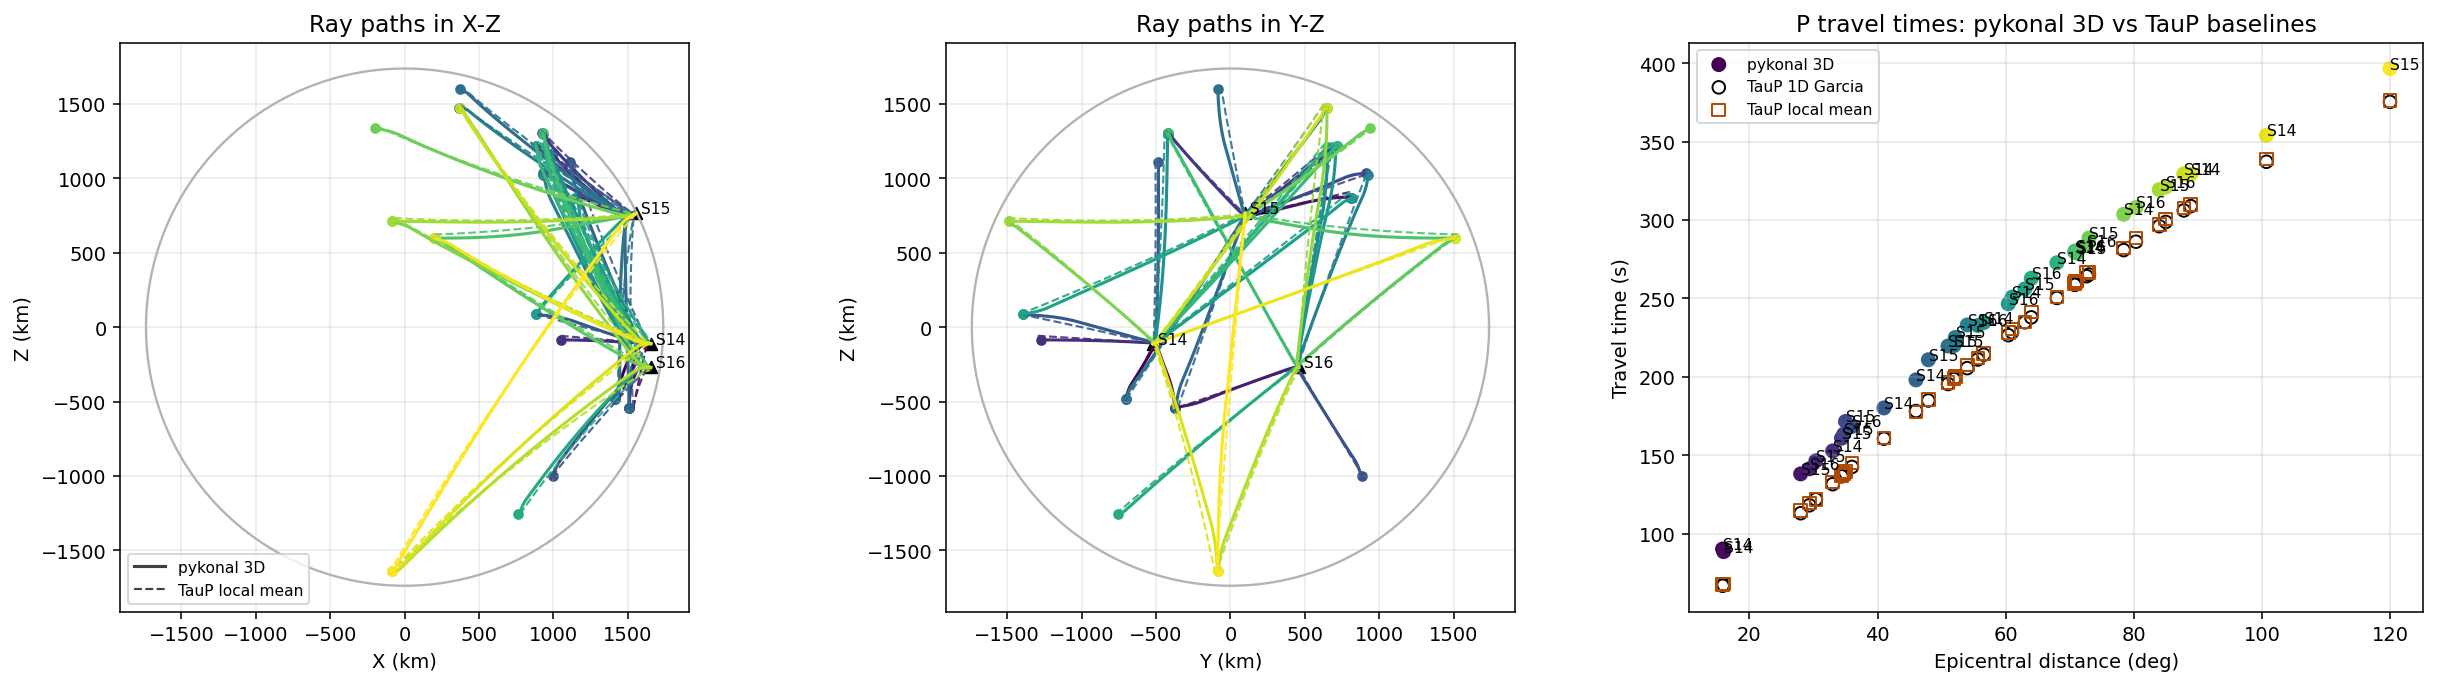

In [283]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=140)
colors = plt.cm.viridis(np.linspace(0.0, 1.0, max(len(solutions), 1)))
theta = np.linspace(0.0, 2.0 * np.pi, 400)

for ax, pair in zip(axes[:2], [(0, 2, "X", "Z"), (1, 2, "Y", "Z")]):
    ax.plot(RMOON_KM * np.cos(theta), RMOON_KM * np.sin(theta), color="0.7", lw=1.2)

    for color, sol in zip(colors, solutions):
        ray_xyz = np.asarray(sol["ray_xyz"], dtype=float)
        ax.plot(ray_xyz[:, pair[0]], ray_xyz[:, pair[1]], color=color, lw=1.6)
        if sol["taup_local_mean_ray_xyz"] is not None:
            taup_xyz = np.asarray(sol["taup_local_mean_ray_xyz"], dtype=float)
            ax.plot(taup_xyz[:, pair[0]], taup_xyz[:, pair[1]], color=color, lw=1.1, ls="--", alpha=0.9)
        ax.scatter(ray_xyz[-1, pair[0]], ray_xyz[-1, pair[1]], color=color, s=20)

    for station_name, info in APOLLO_STATIONS.items():
        st_xyz = latlon_depth_to_xyz(info["lat"], info["lon"], 0.0)
        ax.scatter(st_xyz[pair[0]], st_xyz[pair[1]], marker="^", color="k", s=35)
        ax.text(st_xyz[pair[0]], st_xyz[pair[1]], f" {station_name}", fontsize=8)

    ax.set_aspect("equal")
    ax.set_xlabel(f"{pair[2]} (km)")
    ax.set_ylabel(f"{pair[3]} (km)")
    ax.grid(alpha=0.25)

axes[0].set_title("Ray paths in X-Z")
axes[1].set_title("Ray paths in Y-Z")
axes[0].legend(
    handles=[
        Line2D([0], [0], color="0.25", lw=1.6, label="pykonal 3D"),
        Line2D([0], [0], color="0.25", lw=1.1, ls="--", label="TauP local mean"),
    ],
    loc="lower left",
    fontsize=8,
)

axes[2].scatter(results_df["epi_deg"], results_df["travel_time_pykonal_s"], c=np.arange(len(results_df)), cmap="viridis", s=45, label="pykonal 3D")
axes[2].scatter(results_df["epi_deg"], results_df["travel_time_taup_s"], facecolors="none", edgecolors="black", s=42, label="TauP 1D Garcia")
axes[2].scatter(results_df["epi_deg"], results_df["travel_time_taup_local_mean_s"], marker="s", facecolors="none", edgecolors="#b24a00", s=42, label="TauP local mean")
for row in results_df.itertuples(index=False):
    axes[2].text(row.epi_deg + 0.05, row.travel_time_pykonal_s, row.station, fontsize=8)

axes[2].set_xlabel("Epicentral distance (deg)")
axes[2].set_ylabel("Travel time (s)")
axes[2].set_title("P travel times: pykonal 3D vs TauP baselines")
axes[2].grid(alpha=0.3)
axes[2].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()


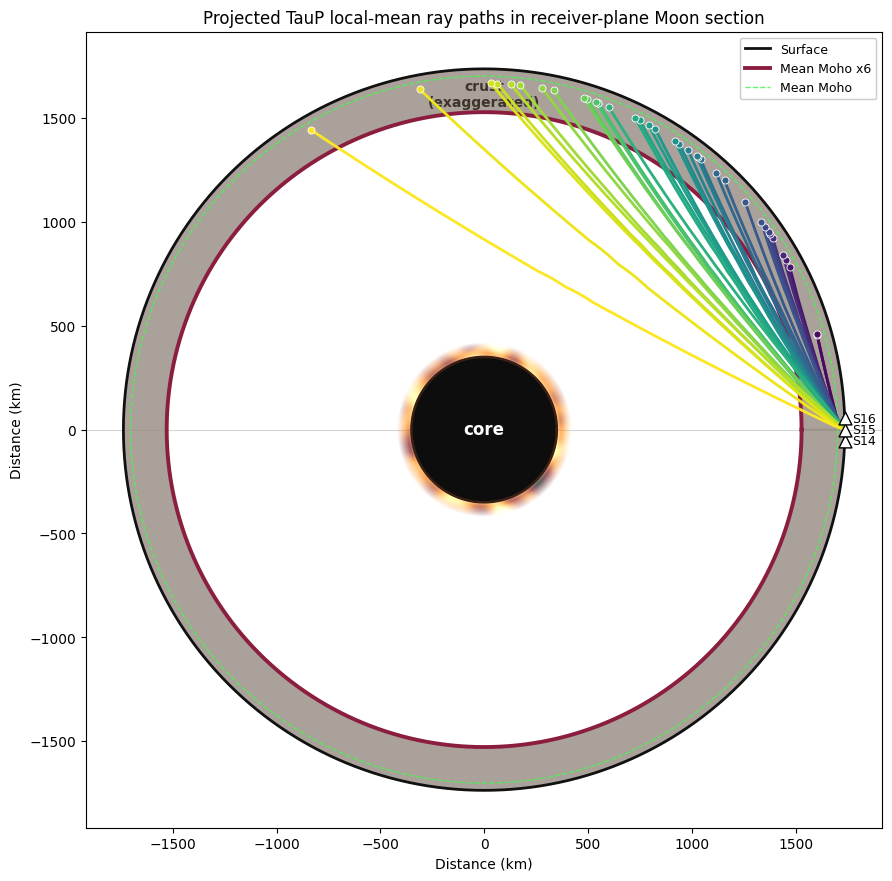

In [284]:
CORE_RADIUS_KM = 350.0
MOHO_EXAGGERATION = 6.0
MAGMA_INNER_FACTOR = 0.90
MAGMA_OUTER_FACTOR = 1.20
MAGMA_FADE_KM = 80.0
MAGMA_PIXELS = 500
MAGMA_RANDOM_SEED = 7

mean_crust_km = float(grail_crust_km.mean())
mean_moho_radius_km = RMOON_KM - mean_crust_km
mean_moho_ex_radius_km = max(CORE_RADIUS_KM * 1.05, RMOON_KM - MOHO_EXAGGERATION * mean_crust_km)

theta = np.linspace(0.0, 2.0 * np.pi, 721)
x_surface_circle = RMOON_KM * np.cos(theta)
z_surface_circle = RMOON_KM * np.sin(theta)
x_moho_circle = mean_moho_radius_km * np.cos(theta)
z_moho_circle = mean_moho_radius_km * np.sin(theta)
x_moho_ex_circle = mean_moho_ex_radius_km * np.cos(theta)
z_moho_ex_circle = mean_moho_ex_radius_km * np.sin(theta)
x_core_circle = CORE_RADIUS_KM * np.cos(theta)
z_core_circle = CORE_RADIUS_KM * np.sin(theta)

x_crust_poly = np.concatenate([x_surface_circle, x_moho_ex_circle[::-1]])
z_crust_poly = np.concatenate([z_surface_circle, z_moho_ex_circle[::-1]])

crust_color = "#988e84"
moho_color = "#8b1e3f"
true_moho_color = "#49f34f"

def project_ray_to_receiver_plane(ray_xyz, source_xyz, receiver_xyz):
    ray_xyz = np.asarray(ray_xyz, dtype=float)
    source_xyz = np.asarray(source_xyz, dtype=float)
    receiver_xyz = np.asarray(receiver_xyz, dtype=float)

    e1 = receiver_xyz / np.linalg.norm(receiver_xyz)
    e2 = source_xyz - np.dot(source_xyz, e1) * e1
    if np.linalg.norm(e2) < 1e-10:
        trial = np.array([0.0, 0.0, 1.0])
        e2 = trial - np.dot(trial, e1) * e1
        if np.linalg.norm(e2) < 1e-10:
            trial = np.array([0.0, 1.0, 0.0])
            e2 = trial - np.dot(trial, e1) * e1
    e2 = e2 / np.linalg.norm(e2)

    u = ray_xyz @ e1
    v = ray_xyz @ e2
    src_uv = np.array([source_xyz @ e1, source_xyz @ e2])
    rec_uv = np.array([receiver_xyz @ e1, receiver_xyz @ e2])

    if src_uv[1] < 0.0:
        v = -v
        src_uv[1] = -src_uv[1]
        rec_uv[1] = -rec_uv[1]

    return u, v, src_uv, rec_uv

fig, ax = plt.subplots(figsize=(9, 9), facecolor="white")
ax.set_facecolor("white")

core_inner = CORE_RADIUS_KM * MAGMA_INNER_FACTOR
core_outer = CORE_RADIUS_KM * MAGMA_OUTER_FACTOR
magma_x = np.linspace(-core_outer, core_outer, MAGMA_PIXELS)
magma_y = np.linspace(-core_outer, core_outer, MAGMA_PIXELS)
magma_X, magma_Y = np.meshgrid(magma_x, magma_y)
magma_R = np.sqrt(magma_X**2 + magma_Y**2)
magma_mask = (magma_R >= core_inner) & (magma_R <= core_outer)

rng = np.random.default_rng(MAGMA_RANDOM_SEED)
noise = rng.random((MAGMA_PIXELS, MAGMA_PIXELS))
try:
    from scipy.ndimage import gaussian_filter
    noise = gaussian_filter(noise, sigma=20)
except ModuleNotFoundError:
    pass

magma_field = np.where(magma_mask, noise, np.nan)
d_to_inner = magma_R - core_inner
d_to_outer = core_outer - magma_R
alpha_ring = np.clip(np.minimum(d_to_inner, d_to_outer) / MAGMA_FADE_KM, 0.0, 1.0)
alpha_ring[~magma_mask] = 0.0

ax.imshow(
    magma_field,
    extent=[-core_outer, core_outer, -core_outer, core_outer],
    origin="lower",
    cmap="afmhot",
    alpha=alpha_ring,
    zorder=2,
)
ax.fill(x_core_circle, z_core_circle, color="0.05", alpha=1.0, zorder=3)
ax.fill(x_crust_poly, z_crust_poly, color=crust_color, alpha=0.82, zorder=3)
ax.plot(x_surface_circle, z_surface_circle, color="#111111", lw=2.0, zorder=5, label="Surface")
ax.plot(x_core_circle, z_core_circle, color="#3a1f12", lw=1.8, zorder=6)
ax.plot(x_moho_ex_circle, z_moho_ex_circle, color=moho_color, lw=2.8, zorder=7, label=f"Mean Moho x{MOHO_EXAGGERATION:.0f}")
ax.plot(x_moho_circle, z_moho_circle, color=true_moho_color, lw=1.0, ls="--", alpha=0.85, zorder=6, label="Mean Moho")
ax.axhline(0.0, color="#7f8c8d", lw=0.8, alpha=0.35, zorder=1)

colors = plt.cm.viridis(np.linspace(0.0, 1.0, max(len(solutions), 1)))
for color, sol in zip(colors, solutions):
    taup_ray_xyz = sol.get("taup_local_mean_ray_xyz")
    if taup_ray_xyz is None:
        continue
    taup_ray_xyz = np.asarray(taup_ray_xyz, dtype=float)
    source_xyz = np.asarray(sol["source_xyz"], dtype=float)
    receiver_xyz = np.asarray(sol["receiver_xyz"], dtype=float)
    u, v, src_uv, rec_uv = project_ray_to_receiver_plane(taup_ray_xyz, source_xyz, receiver_xyz)
    ax.plot(u, v, color=color, lw=2.0, zorder=8)
    ax.scatter(src_uv[0], src_uv[1], s=26, color=color, edgecolor="white", linewidth=0.6, zorder=9)

station_names = sorted(APOLLO_STATIONS)
label_offsets_km = np.linspace(-55.0, 55.0, max(len(station_names), 1))
for station_name, offset in zip(station_names, label_offsets_km):
    x_station = np.sqrt(max(RMOON_KM**2 - offset**2, 0.0))
    ax.scatter(x_station, offset, marker="^", s=85, facecolor="white", edgecolor="black", linewidth=1.0, zorder=10)
    ax.text(x_station + 35.0, offset, station_name, fontsize=9, va="center")

ax.text(0.0, 0.0, "core", ha="center", va="center", color="white", fontsize=12, weight="bold")
ax.text(0.0, RMOON_KM - 120.0, "crust\n(exaggerated)", ha="center", va="center", color="#3e342c", fontsize=10, weight="bold")

margin = 180.0
ax.set_xlim(-(RMOON_KM + margin), RMOON_KM + margin)
ax.set_ylim(-(RMOON_KM + margin), RMOON_KM + margin)
ax.set_aspect("equal")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Distance (km)")
ax.set_title("Projected TauP local-mean ray paths in receiver-plane Moon section")
ax.legend(loc="upper right", fontsize=9, frameon=True, facecolor="white", edgecolor="0.75")
plt.tight_layout()
plt.show()


Arrival-time comparison from results sheet vs mean TauP:
Event selection: legacy_mp0_kn5_kpp2
Rows in current selected catalog: 37
Non-null counts: {'current_mean_pick': 37, 'lognonne': 24, 'nakamura': 21, 'margarit': 13, 'taup_trace_start': 37}


,event,station,epi_deg,starttime_dt,origin_time_utc,origin_time_method,t0_s_mean,lognonne_trace_start_s,nakamura_trace_start_s,margarit_trace_start_s,taup_trace_start_s,t0_mean_minus_taup_trace_start_s,lognonne_minus_taup_trace_start_s,nakamura_minus_taup_trace_start_s,margarit_minus_taup_trace_start_s
0,1975-02-13 21:54:00.011000+00:00__S14,S14,15.812846,1975-02-13 21:54:00.011000+00:00,1975-02-13 22:03:00+00:00,matched,660.099598,657.889,658.289,NaN,607.436485,52.663113,50.452515,50.852515,NaN
1,1976-03-08 14:33:00.012000+00:00__S14,S14,15.971745,1976-03-08 14:33:00.012000+00:00,1976-03-08 14:42:00+00:00,matched,612.855561,619.988,621.788,NaN,608.018896,4.836665,11.969104,13.769104,NaN
2,1973-02-08 22:43:10.015000+00:00__S15,S15,28.000000,1973-02-08 22:43:10.015000+00:00,1973-02-08 22:52:10.015000+00:00,margarit_plus_540s,660.052318,NaN,NaN,649.985,654.612502,5.439817,NaN,NaN,-4.627502
3,1976-03-08 14:33:00.004000+00:00__S16,S16,29.358303,1976-03-08 14:33:00.004000+00:00,1976-03-08 14:42:00+00:00,matched,657.654689,651.996,664.996,NaN,659.460716,-1.806027,-7.464716,5.535284,NaN
4,1976-01-04 11:09:00.018000+00:00__S15,S15,30.373555,1976-01-04 11:09:00.018000+00:00,1976-01-04 11:18:00+00:00,matched,709.641091,715.082,713.082,NaN,661.689820,47.951271,53.392180,51.392180,NaN
5,1975-01-13 00:17:20.011000+00:00__S14,S14,33.000000,1975-01-13 00:17:20.011000+00:00,1975-01-13 00:26:20.011000+00:00,margarit_plus_540s,680.879790,NaN,NaN,684.989,672.878465,8.001325,NaN,NaN,12.110535
6,1976-03-06 10:03:00.015000+00:00__S15,S15,34.369254,1976-03-06 10:03:00.015000+00:00,1976-03-06 10:12:00+00:00,matched,688.235848,698.585,695.085,NaN,677.157792,11.078056,21.427208,17.927208,NaN
7,1972-12-06 22:59:00.004000+00:00__S15,S15,34.718490,1972-12-06 22:59:00.004000+00:00,1972-12-06 23:08:00+00:00,matched,699.288790,706.996,NaN,NaN,678.404486,20.884304,28.591514,NaN,NaN
8,1976-01-12 08:09:05.013000+00:00__S15,S15,35.000000,1976-01-12 08:09:05.013000+00:00,1976-01-12 08:18:05.013000+00:00,margarit_plus_540s,707.577304,NaN,NaN,694.987,679.837369,27.739934,NaN,NaN,15.149631
9,1974-04-19 13:26:15.008000+00:00__S16,S16,36.000000,1974-04-19 13:26:15.008000+00:00,1974-04-19 13:35:15.008000+00:00,margarit_plus_540s,698.539160,NaN,NaN,664.992,685.145116,13.394044,NaN,NaN,-20.153116


This plot uses the results-sheet columns directly: `t0_s_mean`, `lognonne_P_utc`, `nakamura_P_utc`, `margarit_P_utc`.
TauP is shifted onto the same trace-start reference using `origin_time_utc - starttime`.
Margarit-only fallback rows using `origin_time_utc = starttime + 540 s`: 13
Saved comparison table to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/arrival_time_comparison_legacy_mp0_kn5_kpp2_vs_mean_taup.csv


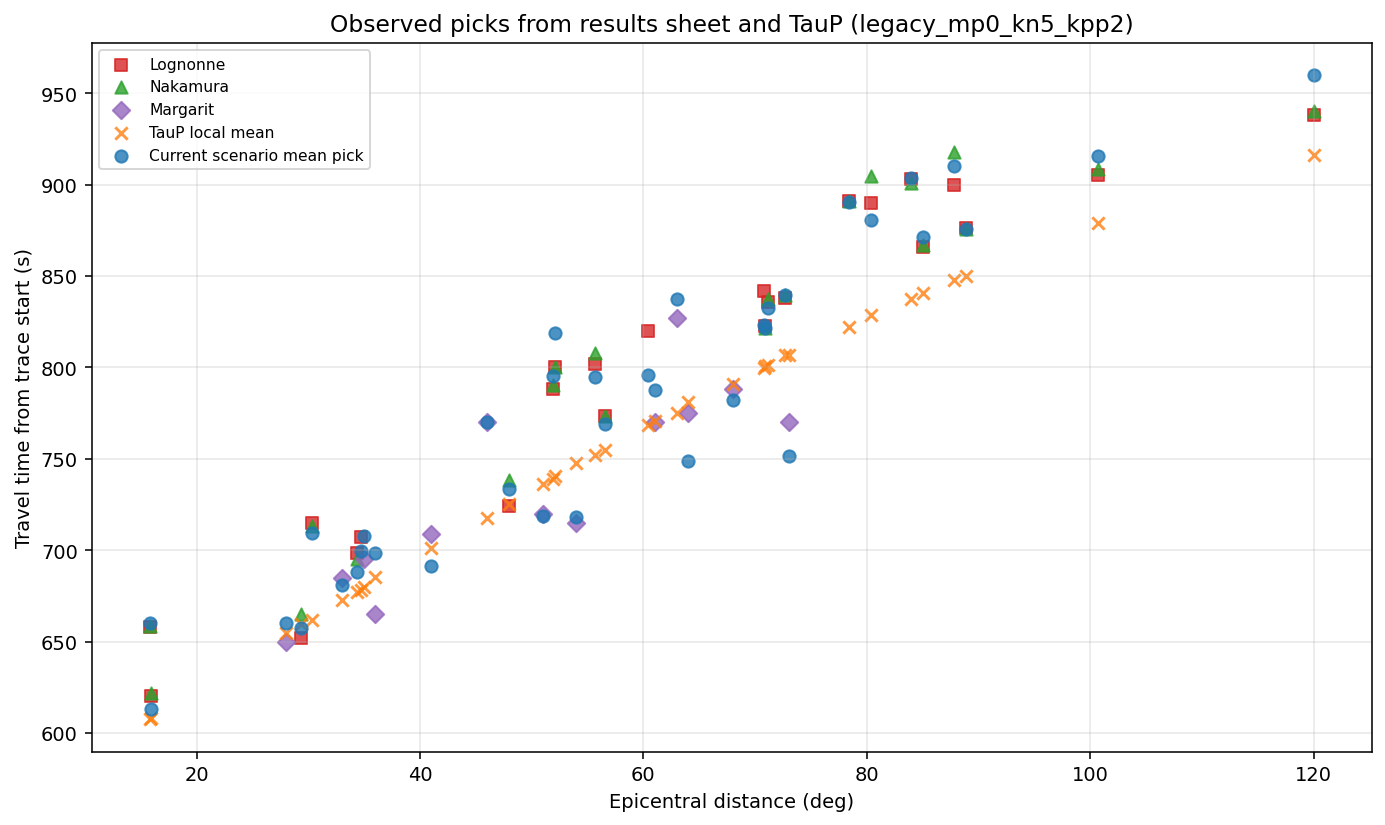

In [285]:
comparison_sheet = SHEET
comparison_usecols = [
    "starttime",
    "station",
    "fc_hz",
    "epi_deg",
    "t0_s_mean",
    "t0_dt_mean",
    "lognonne_P_utc",
    "nakamura_P_utc",
    "margarit_P_utc",
]
comparison_csv = RESULTS_CSV.parent / f"arrival_time_comparison_{EVENT_SELECTION_NAME}_vs_mean_taup.csv"

comparison_df = pd.read_excel(XLSX, sheet_name=comparison_sheet, usecols=comparison_usecols).copy()
comparison_df["station"] = comparison_df["station"].astype(str).str.strip()
comparison_df["fc_hz"] = pd.to_numeric(comparison_df["fc_hz"], errors="coerce")
comparison_df["epi_deg"] = pd.to_numeric(comparison_df["epi_deg"], errors="coerce")
comparison_df["t0_s_mean"] = pd.to_numeric(comparison_df["t0_s_mean"], errors="coerce")
comparison_df["starttime_dt"] = pd.to_datetime(comparison_df["starttime"], errors="coerce", utc=True)
for col in ["t0_dt_mean", "lognonne_P_utc", "nakamura_P_utc", "margarit_P_utc"]:
    comparison_df[col] = pd.to_datetime(comparison_df[col], errors="coerce", utc=True)
comparison_df = comparison_df.loc[np.isclose(comparison_df["fc_hz"], FC, atol=1e-6)].copy()
comparison_df["event"] = comparison_df["starttime_dt"].astype(str) + "__" + comparison_df["station"]
comparison_df = comparison_df.merge(
    catalog_df[["event", "station", "epi_deg"]].drop_duplicates(),
    on=["event", "station", "epi_deg"],
    how="inner",
)
comparison_df = comparison_df.sort_values(["starttime_dt", "station"]).drop_duplicates(subset=["event", "station"], keep="first").reset_index(drop=True)

input_df = pd.read_excel(
    XLSX,
    sheet_name="input_df",
    usecols=[
        "start_time_utc",
        "epi_S14",
        "epi_S15",
        "epi_S16",
        "lognonne_14P_utc",
        "lognonne_15P_utc",
        "lognonne_16P_utc",
        "nakamura_14P_utc",
        "nakamura_15P_utc",
        "nakamura_16P_utc",
    ],
).copy()
for col in input_df.columns:
    if col.endswith("_utc"):
        input_df[col] = pd.to_datetime(input_df[col], errors="coerce", utc=True)

origin_rows = []
for station in ["S14", "S15", "S16"]:
    station_num = station[1:]
    origin_rows.append(
        pd.DataFrame(
            {
                "station": station,
                "origin_time_utc": input_df["start_time_utc"],
                "epi_deg_input": pd.to_numeric(input_df[f"epi_{station}"], errors="coerce"),
                "lognonne_P_utc_input": input_df.get(f"lognonne_{station_num}P_utc"),
                "nakamura_P_utc_input": input_df.get(f"nakamura_{station_num}P_utc"),
            }
        )
    )
input_long = pd.concat(origin_rows, ignore_index=True)


def resolve_origin_time(row, input_long):
    candidates = input_long.loc[input_long["station"].eq(row["station"])].copy()
    if candidates.empty:
        return pd.NaT

    for obs_col, ref_col in [
        ("lognonne_P_utc", "lognonne_P_utc_input"),
        ("nakamura_P_utc", "nakamura_P_utc_input"),
    ]:
        obs_value = row.get(obs_col)
        if pd.notna(obs_value):
            matches = candidates.loc[candidates[ref_col].eq(obs_value)]
            if len(matches) == 1:
                return matches["origin_time_utc"].iloc[0]

    epi_deg = pd.to_numeric(row.get("epi_deg", np.nan), errors="coerce")
    if np.isfinite(epi_deg):
        epi_matches = candidates.loc[np.isclose(candidates["epi_deg_input"], epi_deg, atol=1e-3, equal_nan=False)]
        if len(epi_matches) == 1:
            return epi_matches["origin_time_utc"].iloc[0]

    return pd.NaT


comparison_df["origin_time_utc"] = comparison_df.apply(resolve_origin_time, axis=1, input_long=input_long)
comparison_df["origin_time_method"] = np.where(comparison_df["origin_time_utc"].notna(), "matched", pd.NA)
margarit_fallback_mask = (
    comparison_df["origin_time_utc"].isna()
    & comparison_df["margarit_P_utc"].notna()
)
comparison_df.loc[margarit_fallback_mask, "origin_time_utc"] = (
    comparison_df.loc[margarit_fallback_mask, "starttime_dt"] + pd.to_timedelta(540.0, unit="s")
)
comparison_df.loc[margarit_fallback_mask, "origin_time_method"] = "margarit_plus_540s"
comparison_df["origin_minus_trace_start_s"] = (comparison_df["origin_time_utc"] - comparison_df["starttime_dt"]).dt.total_seconds()

taup_results_df = results_df.copy()
if taup_results_df.empty:
    print("`results_df` is empty in memory, so no mean TauP travel times are available for this comparison cell.")
comparison_df = comparison_df.merge(
    taup_results_df[["event", "station", "travel_time_taup_local_mean_s"]].drop_duplicates(),
    on=["event", "station"],
    how="left",
)
comparison_df["travel_time_taup_local_mean_s"] = pd.to_numeric(comparison_df["travel_time_taup_local_mean_s"], errors="coerce")
comparison_df["taup_trace_start_s"] = comparison_df["travel_time_taup_local_mean_s"] + comparison_df["origin_minus_trace_start_s"]

comparison_df["lognonne_trace_start_s"] = (comparison_df["lognonne_P_utc"] - comparison_df["starttime_dt"]).dt.total_seconds()
comparison_df["nakamura_trace_start_s"] = (comparison_df["nakamura_P_utc"] - comparison_df["starttime_dt"]).dt.total_seconds()
comparison_df["margarit_trace_start_s"] = (comparison_df["margarit_P_utc"] - comparison_df["starttime_dt"]).dt.total_seconds()
comparison_df["t0_mean_minus_taup_trace_start_s"] = comparison_df["t0_s_mean"] - comparison_df["taup_trace_start_s"]
comparison_df["lognonne_minus_taup_trace_start_s"] = comparison_df["lognonne_trace_start_s"] - comparison_df["taup_trace_start_s"]
comparison_df["nakamura_minus_taup_trace_start_s"] = comparison_df["nakamura_trace_start_s"] - comparison_df["taup_trace_start_s"]
comparison_df["margarit_minus_taup_trace_start_s"] = comparison_df["margarit_trace_start_s"] - comparison_df["taup_trace_start_s"]

comparison_display_cols = [
    "event",
    "station",
    "epi_deg",
    "starttime_dt",
    "origin_time_utc",
    "origin_time_method",
    "t0_s_mean",
    "lognonne_trace_start_s",
    "nakamura_trace_start_s",
    "margarit_trace_start_s",
    "taup_trace_start_s",
    "t0_mean_minus_taup_trace_start_s",
    "lognonne_minus_taup_trace_start_s",
    "nakamura_minus_taup_trace_start_s",
    "margarit_minus_taup_trace_start_s",
]
comparison_view = comparison_df[comparison_display_cols].sort_values(["epi_deg", "station", "event"], na_position="last").reset_index(drop=True)
comparison_csv.parent.mkdir(parents=True, exist_ok=True)
comparison_view.to_csv(comparison_csv, index=False)

counts = {
    "current_mean_pick": int(pd.to_numeric(comparison_df["t0_s_mean"], errors="coerce").notna().sum()),
    "lognonne": int(pd.to_numeric(comparison_df["lognonne_trace_start_s"], errors="coerce").notna().sum()),
    "nakamura": int(pd.to_numeric(comparison_df["nakamura_trace_start_s"], errors="coerce").notna().sum()),
    "margarit": int(pd.to_numeric(comparison_df["margarit_trace_start_s"], errors="coerce").notna().sum()),
    "taup_trace_start": int(pd.to_numeric(comparison_df["taup_trace_start_s"], errors="coerce").notna().sum()),
}
print("Arrival-time comparison from results sheet vs mean TauP:")
print(f"Event selection: {EVENT_SELECTION_NAME}")
print(f"Rows in current selected catalog: {len(comparison_df)}")
print(f"Non-null counts: {counts}")
display(comparison_view)
fallback_count = int(margarit_fallback_mask.sum())
print("This plot uses the results-sheet columns directly: `t0_s_mean`, `lognonne_P_utc`, `nakamura_P_utc`, `margarit_P_utc`.")
print("TauP is shifted onto the same trace-start reference using `origin_time_utc - starttime`.")
print(f"Margarit-only fallback rows using `origin_time_utc = starttime + 540 s`: {fallback_count}")
print(f"Saved comparison table to: {comparison_csv}")

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)
plot_specs = [
    ("lognonne_trace_start_s", "Lognonne", "#d62728", "s"),
    ("nakamura_trace_start_s", "Nakamura", "#2ca02c", "^"),
    ("margarit_trace_start_s", "Margarit", "#9467bd", "D"),
    ("taup_trace_start_s", "TauP local mean", "#ff7f0e", "x"),
    ("t0_s_mean", "Current scenario mean pick", "#1f77b4", "o"),

]
for ycol, label, color, marker in plot_specs:
    y_values = pd.to_numeric(comparison_df[ycol], errors="coerce")
    x_values = pd.to_numeric(comparison_df["epi_deg"], errors="coerce")
    mask = np.isfinite(x_values) & np.isfinite(y_values)
    ax.scatter(
        x_values[mask],
        y_values[mask],
        s=40,
        marker=marker,
        color=color,
        alpha=0.8,
        label=label,
    )

ax.set_xlabel("Epicentral distance (deg)")
ax.set_ylabel("Travel time from trace start (s)")
ax.set_title(f"Observed picks from results sheet and TauP ({EVENT_SELECTION_NAME})")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


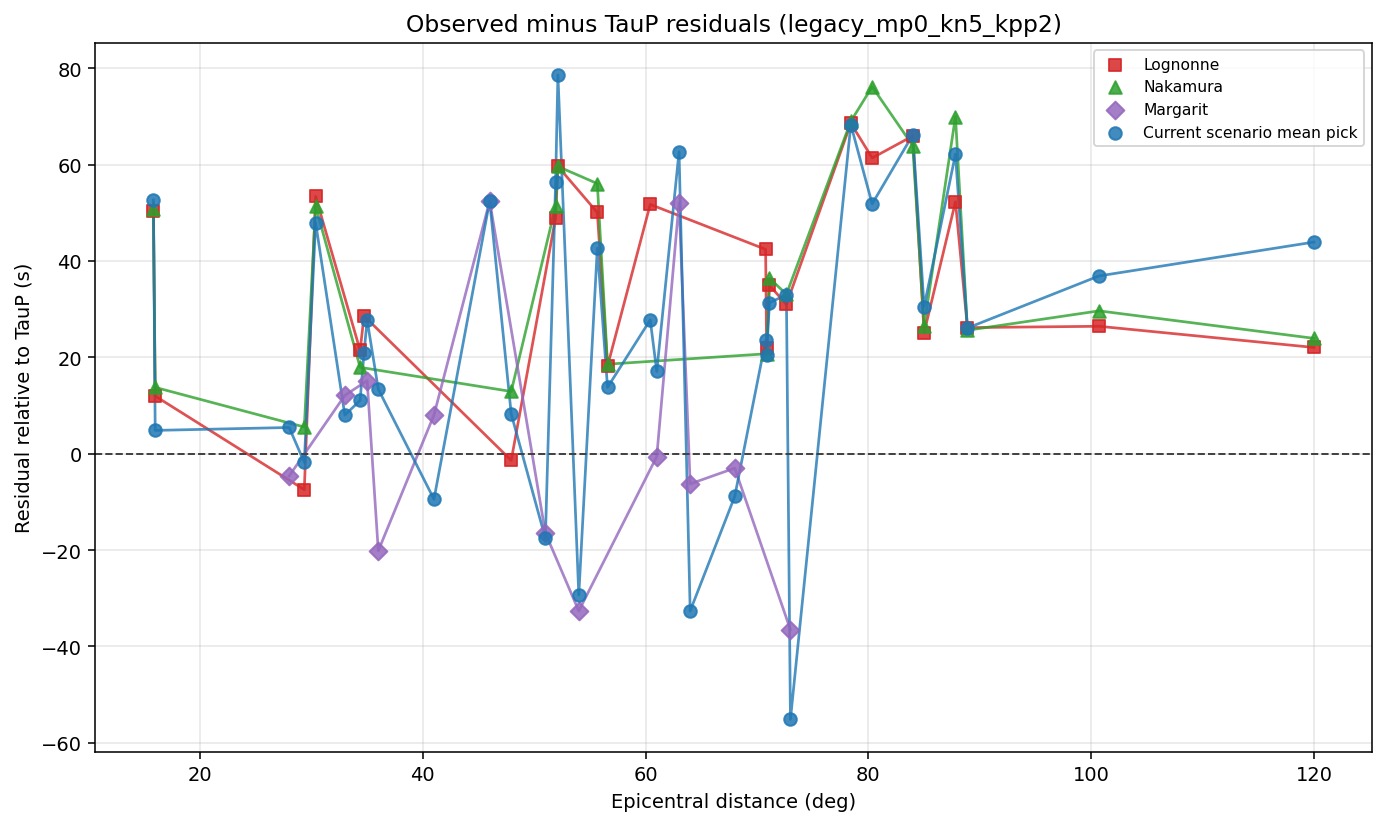

In [286]:
residual_plot_specs = [
    ("lognonne_minus_taup_trace_start_s", "Lognonne", "#d62728", "s"),
    ("nakamura_minus_taup_trace_start_s", "Nakamura", "#2ca02c", "^"),
    ("margarit_minus_taup_trace_start_s", "Margarit", "#9467bd", "D"),
    ("t0_mean_minus_taup_trace_start_s", "Current scenario mean pick", "#1f77b4", "o"),
]

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)
x_values = pd.to_numeric(comparison_df["epi_deg"], errors="coerce")

for ycol, label, color, marker in residual_plot_specs:
    y_values = pd.to_numeric(comparison_df[ycol], errors="coerce")
    mask = np.isfinite(x_values) & np.isfinite(y_values)
    if not mask.any():
        continue
    plot_df = pd.DataFrame({"epi_deg": x_values[mask], "residual_s": y_values[mask]}).sort_values("epi_deg")
    ax.plot(plot_df["epi_deg"], plot_df["residual_s"], color=color, lw=1.4, alpha=0.8)
    ax.scatter(
        plot_df["epi_deg"],
        plot_df["residual_s"],
        s=42,
        marker=marker,
        color=color,
        alpha=0.85,
        label=label,
        zorder=3,
    )

ax.axhline(0.0, color="0.25", lw=1.0, ls="--")
ax.set_xlabel("Epicentral distance (deg)")
ax.set_ylabel("Residual relative to TauP (s)")
ax.set_title(f"Observed minus TauP residuals ({EVENT_SELECTION_NAME})")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()
